In [1]:
import os
os.chdir(r'C:\Users\preet\OneDrive\Desktop\Online Courses Project')
print(os.getcwd())

C:\Users\preet\OneDrive\Desktop\Online Courses Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Online_Courses.csv')
print(df.shape)
df.head()

(8092, 45)


,Unnamed: 0,Title,URL,Short Intro,Category,Sub-Category,Course Type,Language,Subtitle Languages,Skills,...,Course Short Intro,Weekly study,Premium course,What's include,Rank,Created by,Program,Number of ratings,Price,COURSE CATEGORIES
0,0,Machine Learning Specialization,https://www.coursera.org/specializations/machi...,#BreakIntoAI with Machine Learning Specializat...,Data Science,Machine Learning,Specialization,English,Subtitles: English,"Decision Trees, Artificial Neural Network, Log...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Introduction to Data Science Specialization,https://www.coursera.org/specializations/intro...,Launch your career in data science. Gain found...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Relational Database Management S...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Data Science Fundamentals with Python and SQL ...,https://www.coursera.org/specializations/data-...,Build the Foundation for your Data Science car...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Github, Python Programming, Jupy...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Key Technologies for Business Specialization,https://www.coursera.org/specializations/key-t...,Get Ahead with Key Business Technologies. Gain...,Business,Business Essentials,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Artificial Intelligence (AI), Bu...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Deep Learning Specialization,https://www.coursera.org/specializations/deep-...,Become a Machine Learning expert. Master the f...,Data Science,Machine Learning,Specialization,English,"Subtitles: English, Chinese (Traditional), Ara...","Artificial Neural Network, Convolutional Neura...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Check missing values as percentages
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

                       Missing Values  Percentage
Unique Projects                  8092      100.00
6-Month access                   8090       99.98
5-Month access                   8090       99.98
2-Month access                   8082       99.88
3-Month access                   8066       99.68
Created by                       8055       99.54
Rank                             8055       99.54
4-Month access                   8054       99.53
Number of Reviews                8045       99.42
Price                            8027       99.20
Related Programs                 8007       98.95
Monthly access                   7994       98.79
Number of ratings                7966       98.44
Program                          7944       98.17
COURSE CATEGORIES                7944       98.17
Level                            7911       97.76
School                           7821       96.65
What you learn                   7814       96.56
Prequisites                      7811       96.53


In [7]:
# Start fresh from original dataframe
cols_to_keep = ['Title', 'Short Intro', 'Category', 'Sub-Category', 
                'Course Type', 'Language', 'Rating', 
                'Number of viewers', 'Duration', 'Site', 
                'Skills', 'Instructors']

df_clean = df[cols_to_keep].copy()

# Clean Rating
df_clean['Rating'] = df_clean['Rating'].str.replace('stars', '', regex=False).str.strip()
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')

# Clean Number of viewers
df_clean['Number of viewers'] = df_clean['Number of viewers'].str.replace(',', '', regex=False).str.strip()
df_clean['Number of viewers'] = pd.to_numeric(df_clean['Number of viewers'], errors='coerce')

# Clean Duration
def clean_duration(duration):
    if pd.isna(duration):
        return np.nan
    duration = str(duration).lower().strip()
    if 'week' in duration:
        parts = duration.split('week')[0].strip().split()
        for part in reversed(parts):
            if part.isdigit():
                return int(part) * 5
    if 'hour' in duration:
        parts = duration.split('hour')[0].strip().split()
        for part in reversed(parts):
            if part.isdigit():
                return int(part)
    if 'month' in duration:
        parts = duration.split('month')[0].strip().split()
        for part in reversed(parts):
            if part.isdigit():
                return int(part) * 20
    return np.nan

df_clean['Duration_Hours'] = df_clean['Duration'].apply(clean_duration)
df_clean = df_clean.drop(columns=['Duration'])

# Fill missing values
df_clean['Short Intro'] = df_clean['Short Intro'].fillna('No description available')
df_clean['Language'] = df_clean['Language'].fillna('English')
df_clean['Duration_Hours'] = df_clean['Duration_Hours'].fillna(df_clean['Duration_Hours'].median())
df_clean['Skills'] = df_clean['Skills'].fillna('Not specified')
df_clean['Instructors'] = df_clean['Instructors'].fillna('Not specified')

# Drop rows where key columns are missing
df_clean = df_clean.dropna(subset=['Rating', 'Number of viewers', 'Category'])

# Remove duplicates
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=['Title'], keep='first')

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(f"Final shape: {df_clean.shape}")
print(f"\nMissing values:\n{df_clean.isnull().sum()}")
print(f"\nDuplicates: {df_clean.duplicated().sum()}")

Final shape: (2370, 12)

Missing values:
Title                0
Short Intro          0
Category             0
Sub-Category         0
Course Type          0
Language             0
Rating               0
Number of viewers    0
Site                 0
Skills               0
Instructors          0
Duration_Hours       0
dtype: int64

Duplicates: 0


In [8]:
df_clean.to_csv('Online_Courses_Cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")
print(f"Final shape: {df_clean.shape}")

Cleaned dataset saved successfully!
Final shape: (2370, 12)


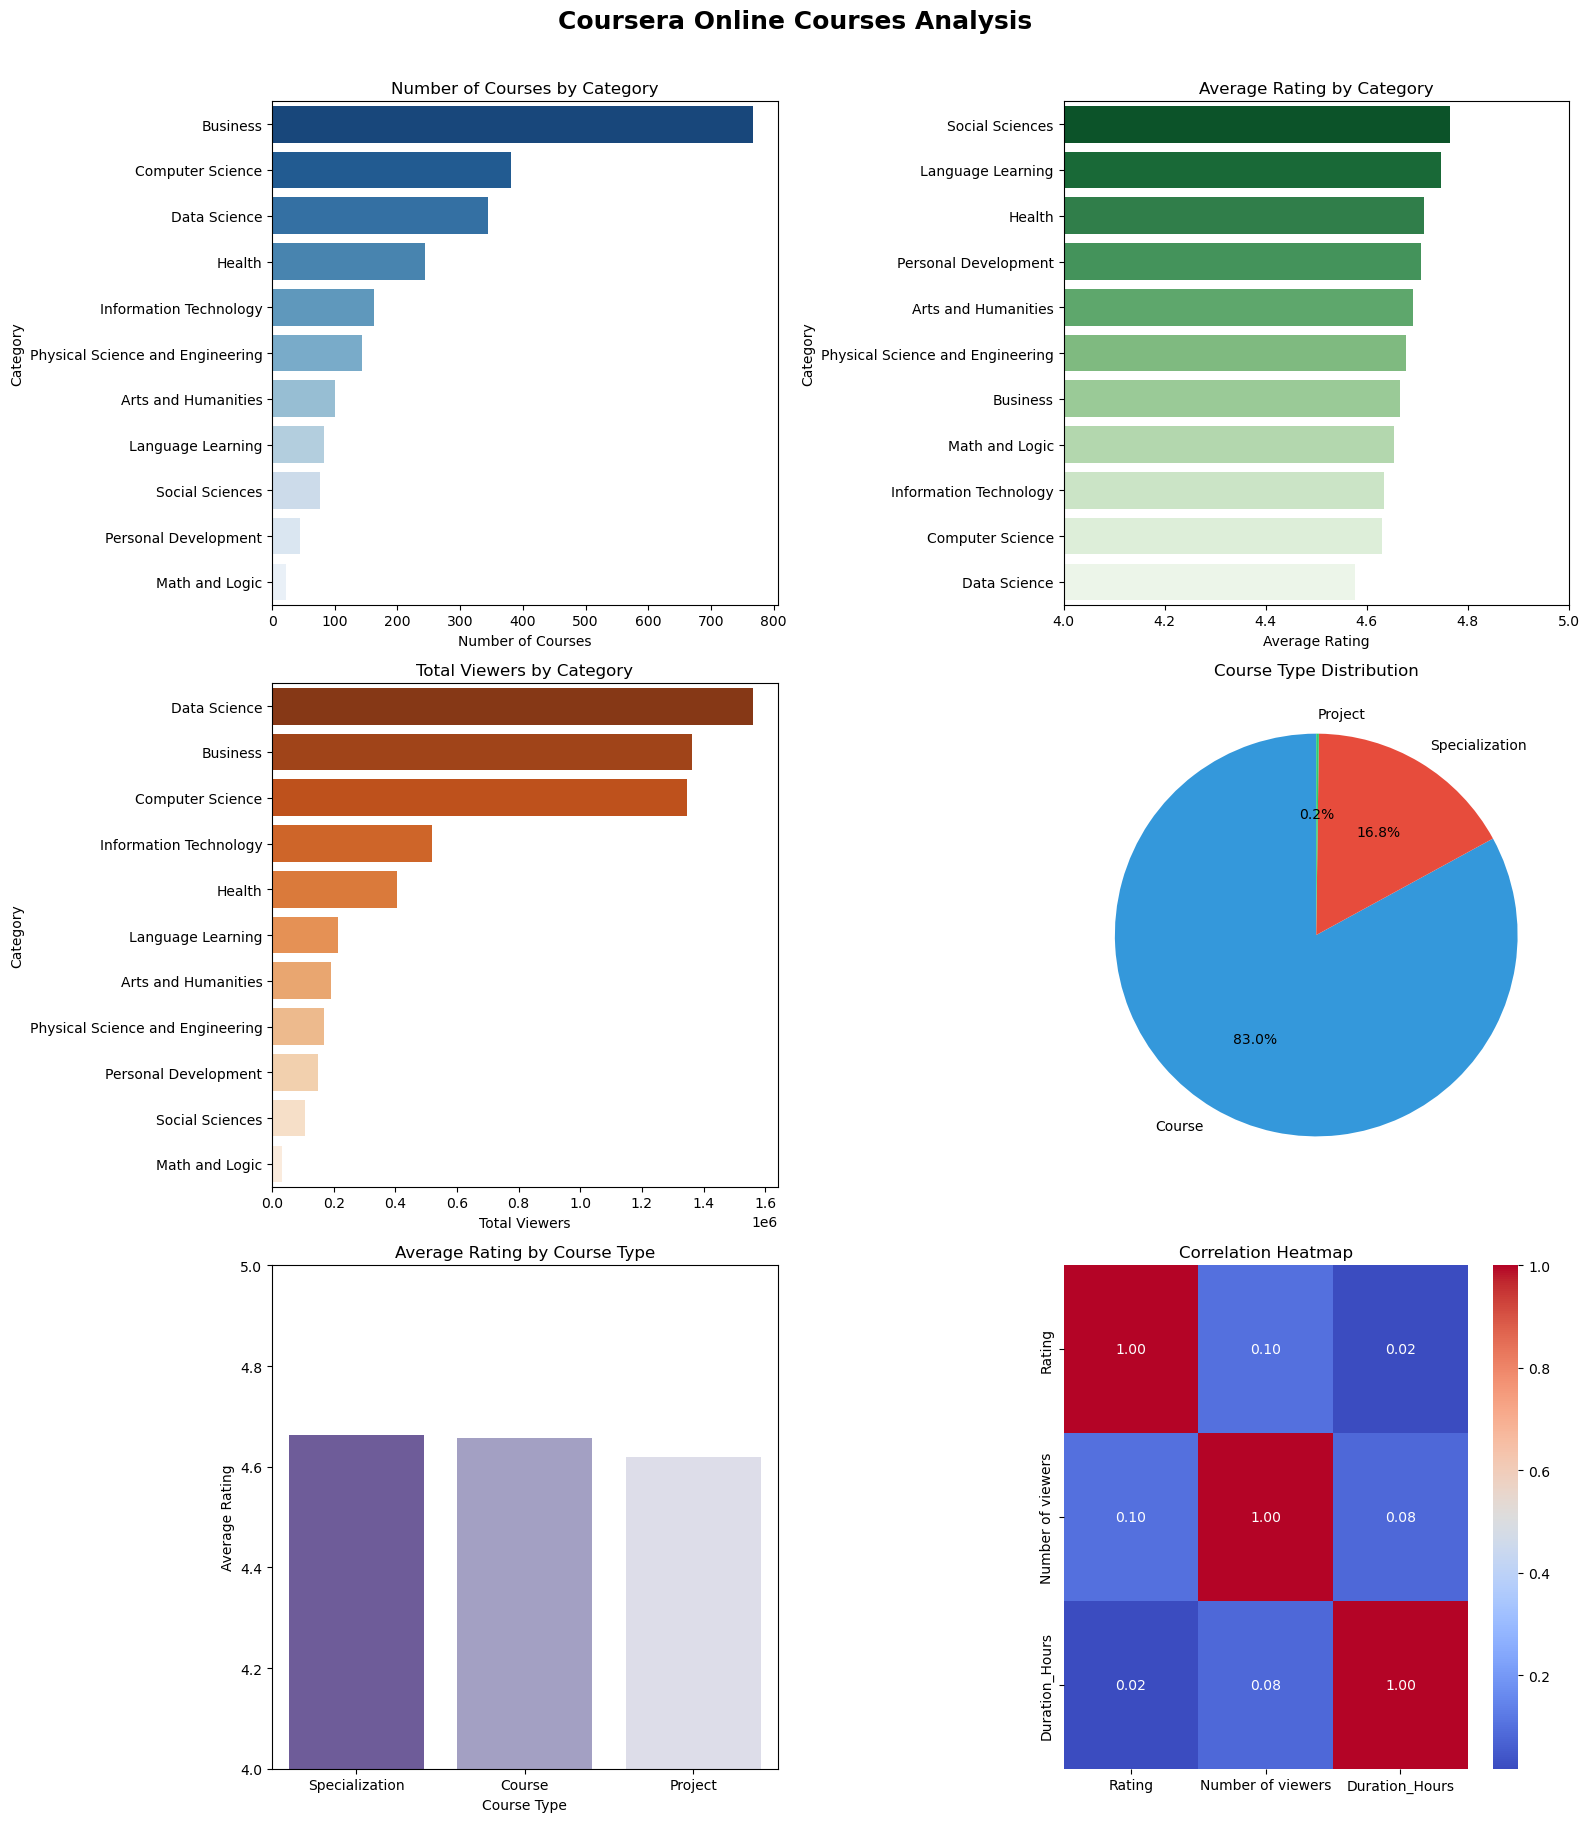

Dashboard saved!


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1 - Number of Courses by Category
category_counts = df_clean['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, palette='Blues_r', legend=False, ax=axes[0,0])
axes[0,0].set_title('Number of Courses by Category')
axes[0,0].set_xlabel('Number of Courses')
axes[0,0].set_ylabel('Category')

# Chart 2 - Average Rating by Category
avg_rating = df_clean.groupby('Category')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.values, y=avg_rating.index, hue=avg_rating.index, palette='Greens_r', legend=False, ax=axes[0,1])
axes[0,1].set_title('Average Rating by Category')
axes[0,1].set_xlabel('Average Rating')
axes[0,1].set_xlim(4.0, 5.0)

# Chart 3 - Total Viewers by Category
total_viewers = df_clean.groupby('Category')['Number of viewers'].sum().sort_values(ascending=False)
sns.barplot(x=total_viewers.values, y=total_viewers.index, hue=total_viewers.index, palette='Oranges_r', legend=False, ax=axes[1,0])
axes[1,0].set_title('Total Viewers by Category')
axes[1,0].set_xlabel('Total Viewers')

# Chart 4 - Course Type Distribution
course_type_counts = df_clean['Course Type'].value_counts()
axes[1,1].pie(course_type_counts.values, labels=course_type_counts.index, autopct='%1.1f%%',
              colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90)
axes[1,1].set_title('Course Type Distribution')

# Chart 5 - Average Rating by Course Type
avg_rating_type = df_clean.groupby('Course Type')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating_type.index, y=avg_rating_type.values, hue=avg_rating_type.index, palette='Purples_r', legend=False, ax=axes[2,0])
axes[2,0].set_title('Average Rating by Course Type')
axes[2,0].set_ylabel('Average Rating')
axes[2,0].set_ylim(4.0, 5.0)

# Chart 6 - Correlation Heatmap
corr = df_clean[['Rating', 'Number of viewers', 'Duration_Hours']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2,1])
axes[2,1].set_title('Correlation Heatmap')

plt.suptitle('Coursera Online Courses Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Coursera_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [2]:
import os
import pandas as pd

os.chdir(r'C:\Users\preet\OneDrive\Desktop\Online Courses Project')
df_clean = pd.read_csv('Online_Courses_Cleaned.csv')
print(df_clean.shape)

(2370, 12)


In [3]:
df_clean.to_csv('Online_Courses_Cleaned_pipe.csv', index=False, sep='|')
print("File saved with pipe separator!")

File saved with pipe separator!


In [2]:
import subprocess
subprocess.run(['pip', 'install', 'mysql-connector-python'], capture_output=True)
print("Installation done!")

Installation done!


In [5]:
import os
import pandas as pd
import numpy as np

os.chdir(r'C:\Users\preet\OneDrive\Desktop\Online Courses Project')
df_clean = pd.read_csv('Online_Courses_Cleaned.csv')
print(df_clean.shape)

(2370, 12)


In [6]:
import mysql.connector
import numpy as np

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='534536',
    database='online_courses'
)

cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS courses")
cursor.execute("""
    CREATE TABLE courses (
        Title VARCHAR(255),
        Short_Intro TEXT,
        Category VARCHAR(100),
        Sub_Category VARCHAR(100),
        Course_Type VARCHAR(50),
        Language VARCHAR(50),
        Rating DECIMAL(3,2),
        Number_of_viewers INT,
        Site VARCHAR(50),
        Skills TEXT,
        Instructors TEXT,
        Duration_Hours DECIMAL(6,2)
    )
""")

df_clean.columns = ['Title', 'Short_Intro', 'Category', 'Sub_Category', 
                    'Course_Type', 'Language', 'Rating', 'Number_of_viewers', 
                    'Site', 'Skills', 'Instructors', 'Duration_Hours']

for _, row in df_clean.iterrows():
    vals = tuple(None if (isinstance(v, float) and np.isnan(v)) else v for v in row)
    cursor.execute("INSERT INTO courses VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)", vals)

conn.commit()
cursor.execute("SELECT COUNT(*) FROM courses")
print(f"Total rows inserted: {cursor.fetchone()[0]}")
cursor.close()
conn.close()

Total rows inserted: 2370
